# Installing dependencies

In [ ]:
!pip install biopython==1.87 numpy pandas==3.0.3 scikit-learn==1.9.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatibl

In [ ]:
!pip -q install condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [ ]:
!conda create -y -n oldenv python=3.7 scikit-learn=0.20.3 biopython numpy pandas pytorch torchvision

Retrieving notices: - \ | done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/oldenv

  added / updated specs:
    - biopython
    - numpy
    - pandas
    - python=3.7
    - pytorch
    - scikit-learn=0.20.3
    - torchvision


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |       7_kmp_llvm           8 KB  conda-forge
    biopython-1.79             |   py37h540881e_2         2.6 MB  conda-forge
    brotli-python-1.0.9        |   py37hd23a5d3_7         352 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    certifi-2024.8.30     

In [ ]:
!conda create -y -n crispor python=3.9 numpy==1.22.4 \
pandas==1.4.2 \
scikit-learn==1.1.1 \
tensorflow==2.9.1 \
keras==2.9.0 \
biopython==1.79 \
joblib==1.1.0

# Fetching required NCBI Databases

Bauer DE, Kamran SC, Lessard S, Xu J, Fujiwara Y, Lin C, Shao Z, Canver MC, Smith EC, Pinello L, Sabo PJ, Vierstra J, Voit RA, Yuan GC, Porteus MH, Stamatoyannopoulos JA, Lettre G, Orkin SH. An erythroid enhancer of BCL11A subject to genetic variation determines fetal hemoglobin level. Science. 2013 Oct 11;342(6155):253-7. doi: 10.1126/science.1242088. PMID: 24115442; PMCID: PMC4018826.

h+58 DNase I hypersensitive site of the BCL11A erythroid enhancer (chr2:60,721,212–60,723,058, hg19) selected as the target region

---

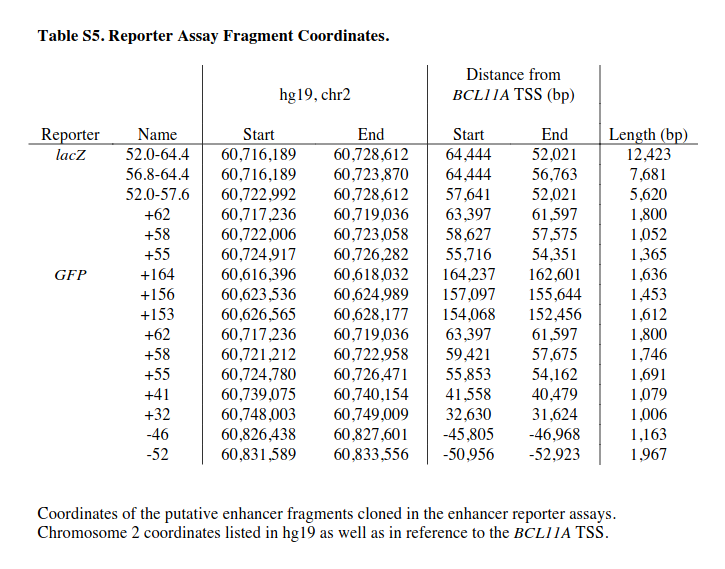

In [ ]:
from Bio import Entrez, SeqIO


handle = Entrez.efetch(
    db="nucleotide",
    id="NC_000002.11",
    rettype="fasta",
    retmode="text",
    seq_start=60721212,
    seq_stop=60722958
)

In [ ]:
record = SeqIO.read(handle, "fasta")

# Save the fetched NCBI region to the exact file name the script expects.
with open("bcl11a_sequence.fa", "w") as f:
    SeqIO.write(record, f, "fasta")

# Ranking CRISPOR

Guides obtained from https://crispor.gi.ucsc.edu/

In [ ]:
import pandas as pd
import io

# FIXED: Modified the header row to contain exactly 12 clean, single-word tokens
guides = """guideId targetSeq mitSpecScore cfdSpecScore offtargetCount targetGenomeGeneLocus Doench RuleSet3-Score Moreno-Mateos-Score Out-of-Frame-Score Lindel-Score GrafEtAlStatus
100forw CTGAGCACATTCTTACGCCTAGG 94  95  77  intergenic:BCL11A-AC009970.1  54  39  -45 85  71  gcc
1091rev CATCGGTGGCCGTTTGCCCAGGG 93  97  35  intergenic:BCL11A-AC009970.1  42  55  10  68  86  GrafOK
1493forw  GAACCCCCTATAAACTAGTCTGG 93  96  43  intergenic:BCL11A-AC009970.1  44  19  -20 68  83  GrafOK
101forw TGAGCACATTCTTACGCCTAGGG 92  98  62  intergenic:BCL11A-AC009970.1  59  62  11  82  79  GrafOK
1092rev CCATCGGTGGCCGTTTGCCCAGG 91  96  56  intergenic:BCL11A-AC009970.1  32  39  -4  67  82  GrafOK
1112forw  CCTGGGCAAACGGCCACCGATGG 91  94  81  intergenic:BCL11A-AC009970.1  51  58  35  61  82  GrafOK
1366rev GATGGCTGAAAAGCGATACAGGG 91  93  86  intergenic:BCL11A-AC009970.1  62  53  84  64  88  GrafOK
1002rev AATTTGTATGCCATGCCGTGTGG 90  92  66  intergenic:BCL11A-AC009970.1  68  47  28  68  85  GrafOK
1152rev GGTTTGGCCTCTGATTAGGGTGG 90  91  75  intergenic:BCL11A-AC009970.1  49  44  -18 61  76  GrafOK
1304forw  GGCCTATGTTATTACCTGTATGG 90  92  81  intergenic:BCL11A-AC009970.1  35  37  -18 59  84  GrafOK
1367rev AGATGGCTGAAAAGCGATACAGG 89  95  112 intergenic:BCL11A-AC009970.1  43  26  -45 65  79  GrafOK
1611forw  CGTATGTGTTGTGATCCCTGTGG 89  93  57  exon:AC009970.1 77  40  95  68  68  GrafOK
79rev CTAGGCGTAAGAATGTGCTCAGG 88  94  43  intergenic:BCL11A-AC009970.1  59  32  90  68  74  GrafOK
1117forw  GCAAACGGCCACCGATGGAGAGG 88  91  76  intergenic:BCL11A-AC009970.1  57  50  83  70  82  GrafOK
1090rev ATCGGTGGCCGTTTGCCCAGGGG 87  95  40  intergenic:BCL11A-AC009970.1  60  73  25  64  83  GrafOK
1105rev CTGGCAGACCTCTCCATCGGTGG 87  90  82  intergenic:BCL11A-AC009970.1  59  64  91  62  79  GrafOK
1085forw  CCAAGAGAGCCTTCCGAAAGAGG 86  94  109 intergenic:BCL11A-AC009970.1  56  46  13  67  84  GrafOK
1316forw  TACCTGTATGGACTTTGCACTGG 86  92  88  intergenic:BCL11A-AC009970.1  44  24  73  56  77  GrafOK
839forw AAGAATATGACGTCAGGGGGAGG 85  87  111 intergenic:BCL11A-AC009970.1  53  77  -39 56  60  GrafOK
1478rev GCAAACCAGACTAGTTTATAGGG 85  91  87  intergenic:BCL11A-AC009970.1  30  36  -97 76  86  GrafOK
1479rev GGCAAACCAGACTAGTTTATAGG 85  90  66  intergenic:BCL11A-AC009970.1  32  21  -114  72  86  tt
883rev  ATCACATATAGGCACCTATCAGG 84  91  123 intergenic:BCL11A-AC009970.1  46  43  -34 71  86  GrafOK
1095forw  CTTCCGAAAGAGGCCCCCCTGGG 84  93  84  intergenic:BCL11A-AC009970.1  57  63  -64 67  80  GrafOK
1298rev TTCCAGTGCAAAGTCCATACAGG 84  92  85  intergenic:BCL11A-AC009970.1  51  49  -32 53  83  GrafOK
240forw CTGTGCATGGCCTCTAAACTGGG 83  93  136 intergenic:BCL11A-AC009970.1  47  56  -19 67  84  GrafOK
1074rev CCAGGGGGGCCTCTTTCGGAAGG 83  87  130 intergenic:BCL11A-AC009970.1  49  58  -5  65  62  GrafOK
1089rev TCGGTGGCCGTTTGCCCAGGGGG 83  92  57  intergenic:BCL11A-AC009970.1  55  86  -1  61  75  GrafOK
1286rev GTCCATACAGGTAATAACATAGG 83  91  86  intergenic:BCL11A-AC009970.1  63  29  42  56  76  GrafOK
1476rev AAACCAGACTAGTTTATAGGGGG 83  91  91  intergenic:BCL11A-AC009970.1  64  50  67  74  85  GrafOK
1505forw  AACTAGTCTGGTTTGCCCATGGG 82  92  81  intergenic:BCL11A-AC009970.1  55  43  -38 62  82  GrafOK
44rev TGTAGGTGTGCCTCACCCATGGG 81  94  86  intergenic:BCL11A-AC009970.1  49  77  20  74  88  GrafOK
476rev  AGTCTGTATTGCCCCAAGTCTGG 81  92  112 intergenic:BCL11A-AC009970.1  47  28  -6  64  69  GrafOK
836forw GAAAAGAATATGACGTCAGGGGG 81  85  183 intergenic:BCL11A-AC009970.1  64  51  51  59  79  GrafOK
1094forw  CCTTCCGAAAGAGGCCCCCCTGG 81  88  124 intergenic:BCL11A-AC009970.1  48  37  0 68  54  GrafOK
1240rev CTCTTAGACATAACACACCAGGG 81  89  117 intergenic:BCL11A-AC009970.1  72  28  55  62  86  GrafOK
1241rev ACTCTTAGACATAACACACCAGG 81  94  89  intergenic:BCL11A-AC009970.1  58  19  40  66  88  GrafOK
1243forw  CTTCAAAGTTGTATTGACCCTGG 81  92  105 intergenic:BCL11A-AC009970.1  56  23  4 62  76  GrafOK
1447rev TCTGAGGTACTGATGGACCTTGG 81  88  137 intergenic:BCL11A-AC009970.1  51  51  35  78  84  GrafOK
1463rev TTATAGGGGGTTCTACTCTGAGG 81  90  87  intergenic:BCL11A-AC009970.1  66  63  83  71  90  GrafOK
1477rev CAAACCAGACTAGTTTATAGGGG 81  87  95  intergenic:BCL11A-AC009970.1  56  24  26  79  91  GrafOK
1506forw  ACTAGTCTGGTTTGCCCATGGGG 81  91  78  intergenic:BCL11A-AC009970.1  60  80  0 62  71  GrafOK
116rev  TGCTTAGCCTGTGTAGCTCAAGG 80  89  113 intergenic:BCL11A-AC009970.1  56  49  -4  62  80  GrafOK
239forw TCTGTGCATGGCCTCTAAACTGG 80  92  123 intergenic:BCL11A-AC009970.1  27  36  -45 66  80  GrafOK
498forw AGACTTGGGGCAATACAGACTGG 80  89  155 intergenic:BCL11A-AC009970.1  60  29  28  60  87  GrafOK
1165forw  CACGCCCCCACCCTAATCAGAGG 80  93  100 intergenic:BCL11A-AC009970.1  64  46  85  68  74  GrafOK
1362rev GCTGAAAAGCGATACAGGGCTGG 80  90  94  intergenic:BCL11A-AC009970.1  52  18  58  71  83  GrafOK
1446rev CTGAGGTACTGATGGACCTTGGG 80  90  127 intergenic:BCL11A-AC009970.1  42  68  1 79  83  tt
45rev ATGTAGGTGTGCCTCACCCATGG 79  93  114 intergenic:BCL11A-AC009970.1  54  59  84  76  80  GrafOK
278rev  TGTTTACAGAGGGGCAACCCAGG 79  92  150 intergenic:BCL11A-AC009970.1  57  47  48  66  81  GrafOK
468forw CCATCTCCCTAATCTCCAATTGG 79  88  143 intergenic:BCL11A-AC009970.1  52  25  -75 73  84  GrafOK
909forw AGGTGCCTATATGTGATGGATGG 79  89  111 intergenic:BCL11A-AC009970.1  53  56  47  74  85  GrafOK
1151rev GTTTGGCCTCTGATTAGGGTGGG 79  89  138 intergenic:BCL11A-AC009970.1  47  29  15  64  75  GrafOK
230rev  ATGGTCACTGCCCAGTTTAGAGG 78  88  115 intergenic:BCL11A-AC009970.1  47  48  -13 67  81  GrafOK
765rev  CTGACCCAAACTAGGAATTGGGG 78  88  124 intergenic:BCL11A-AC009970.1  58  49  42  70  74  GrafOK
835forw GGAAAAGAATATGACGTCAGGGG 78  88  194 intergenic:BCL11A-AC009970.1  61  60  61  63  87  GrafOK
1012forw  TTTTGGGAGTCCACACGGCATGG 78  91  103 intergenic:BCL11A-AC009970.1  57  57  -66 71  86  GrafOK
1059rev TCGGAAGGCTCTCTTGGTGATGG 78  89  103 intergenic:BCL11A-AC009970.1  49  62  57  51  57  GrafOK
1155rev AAGGGTTTGGCCTCTGATTAGGG 78  89  141 intergenic:BCL11A-AC009970.1  37  61  -97 60  64  GrafOK
1350forw  TGCTCTTACTTATGCACACCTGG 78  93  103 intergenic:BCL11A-AC009970.1  41  10  -52 63  85  GrafOK
129forw AATACATCCTTGAGCTACACAGG 77  86  142 intergenic:BCL11A-AC009970.1  55  37  51  63  66  GrafOK
455rev  GGCTTTGCCAATTGGAGATTAGG 77  87  133 intergenic:BCL11A-AC009970.1  34  24  -100  63  67  GrafOK
1351forw  GCTCTTACTTATGCACACCTGGG 77  92  107 intergenic:BCL11A-AC009970.1  62  31  50  60  88  GrafOK
767rev  TTCTGACCCAAACTAGGAATTGG 76  84  171 intergenic:BCL11A-AC009970.1  30  31  -72 64  72  GrafOK
889forw CACAGTAGCTGGTACCTGATAGG 76  71  256 intergenic:BCL11A-AC009970.1  50  67  -15 66  87  GrafOK
1088rev CGGTGGCCGTTTGCCCAGGGGGG 76  89  103 intergenic:BCL11A-AC009970.1  62  96  26  66  85  GrafOK
1436forw  CTAGCTGCCTTCCTTATCACAGG 76  89  147 intergenic:BCL11A-AC009970.1  53  40  14  60  74  GrafOK
304forw TTGCCCCTCTGTAAACAAGGAGG 75  78  186 intergenic:BCL11A-AC009970.1  74  82  91  51  81  GrafOK
454rev  GCTTTGCCAATTGGAGATTAGGG 75  85  140 intergenic:BCL11A-AC009970.1  44  57  -79 60  72  GrafOK
1156rev GAAGGGTTTGGCCTCTGATTAGG 75  87  155 intergenic:BCL11A-AC009970.1  23  50  2 60  67  GrafOK
1185rev CTAACAGTTGCTTTTATCACAGG 75  88  175 intergenic:BCL11A-AC009970.1  44  26  -159  68  78  GrafOK
980rev  GACTCCCAAAATTGTAAAGGAGG 74  84  136 intergenic:BCL11A-AC009970.1  60  35  48  54  78  GrafOK
1504forw  AAACTAGTCTGGTTTGCCCATGG 74  85  129 intergenic:BCL11A-AC009970.1  50  44  -18 59  81  GrafOK
377forw TTTTGCCAAGATGGGAGTATGGG 73  84  200 intergenic:BCL11A-AC009970.1  55  54  -121  67  67  GrafOK
687rev  AGCATTTTAGTTCACAAGCTCGG 73  88  153 intergenic:BCL11A-AC009970.1  54  32  -126  59  81  GrafOK
780forw CCTTTCCCCAATTCCTAGTTTGG 73  83  263 intergenic:BCL11A-AC009970.1  20  27  -148  54  83  GrafOK
833forw AAGGAAAAGAATATGACGTCAGG 73  83  317 intergenic:BCL11A-AC009970.1  42  53  -14 71  73  GrafOK
834forw AGGAAAAGAATATGACGTCAGGG 73  75  293 intergenic:BCL11A-AC009970.1  61  37  -4  68  83  GrafOK
10rev TCTCTGTTTATTGCCAGTAGTGG 72  82  181 intergenic:BCL11A-AC009970.1  48  45  -30 59  70  GrafOK
43rev GTAGGTGTGCCTCACCCATGGGG 72  85  142 intergenic:BCL11A-AC009970.1  67  70  99  75  84  GrafOK
289rev  TACAACCTCCTTGTTTACAGAGG 72  82  158 intergenic:BCL11A-AC009970.1  46  37  -24 68  81  GrafOK
1007forw  TACAATTTTGGGAGTCCACACGG 72  84  162 intergenic:BCL11A-AC009970.1  58  32  -62 70  87  GrafOK
1352forw  CTCTTACTTATGCACACCTGGGG 72  87  139 intergenic:BCL11A-AC009970.1  67  66  27  61  82  GrafOK
252forw TCTAAACTGGGCAGTGACCATGG 71  88  173 intergenic:BCL11A-AC009970.1  56  34  55  63  72  GrafOK
323rev  TTTATAAGACATTAGGGTATTGG 71  79  229 intergenic:BCL11A-AC009970.1  40  32  -56 61  73  GrafOK
714rev  AGGTGTAACTAATAAATACCAGG 71  89  129 intergenic:BCL11A-AC009970.1  62  40  32  74  80  GrafOK
766rev  TCTGACCCAAACTAGGAATTGGG 71  87  164 intergenic:BCL11A-AC009970.1  30  46  -32 63  80  GrafOK
773rev  CTTTTCTTCTGACCCAAACTAGG 71  84  209 intergenic:BCL11A-AC009970.1  42  20  -109  60  70  GrafOK
983rev  GTGGACTCCCAAAATTGTAAAGG 71  79  155 intergenic:BCL11A-AC009970.1  54  30  -51 69  72  GrafOK
1150rev TTTGGCCTCTGATTAGGGTGGGG 71  84  230 intergenic:BCL11A-AC009970.1  41  64  33  66  80  GrafOK
1427rev TGGGTGCTATTCCTGTGATAAGG 71  84  155 intergenic:BCL11A-AC009970.1  48  57  15  58  71  GrafOK
378forw TTTGCCAAGATGGGAGTATGGGG 70  85  208 intergenic:BCL11A-AC009970.1  63  61  -14 65  84  GrafOK
711rev  TGTAACTAATAAATACCAGGAGG 70  78  236 intergenic:BCL11A-AC009970.1  73  28  134 63  79  GrafOK
1552rev TTATATGTAAGCATCACAACAGG 70  88  185 intergenic:BCL11A-AC009970.1  54  38  -1  67  73  GrafOK
172forw GTGATGCTGACAGGCCACATGGG 69  91  159 intergenic:BCL11A-AC009970.1  65  74  63  68  81  GrafOK
851forw TCAGGGGGAGGCAAGTCAGTTGG 69  78  231 intergenic:BCL11A-AC009970.1  50  53  -24 51  76  GrafOK
1143rev TCTGATTAGGGTGGGGGCGTGGG 69  84  188 intergenic:BCL11A-AC009970.1  41  72  -14 61  65  GrafOK
166rev  CGTCTTCCCACTCTCCCATGTGG 68  84  151 intergenic:BCL11A-AC009970.1  64  42  46  67  79  GrafOK
852forw CAGGGGGAGGCAAGTCAGTTGGG 68  88  222 intergenic:BCL11A-AC009970.1  45  71  -47 52  85  GrafOK
894rev  TCCACCCATCCATCACATATAGG 68  87  164 intergenic:BCL11A-AC009970.1  57  32  -29 66  82  GrafOK
913forw GCCTATATGTGATGGATGGGTGG 68  85  128 intergenic:BCL11A-AC009970.1  63  44  73  68  91  GrafOK
1108rev GGACTGGCAGACCTCTCCATCGG 68  86  156 intergenic:BCL11A-AC009970.1  64  69  29  60  79  GrafOK
1384rev GGGAGTTATCTGTAGTGAGATGG 68  78  196 intergenic:BCL11A-AC009970.1  59  58  52  66  80  GrafOK
1404rev AAGGCAGCTAGACAGGACTTGGG 68  85  191 intergenic:BCL11A-AC009970.1  62  68  56  58  82  tt
485forw AATTGGCAAAGCCAGACTTGGGG 67  84  188 intergenic:BCL11A-AC009970.1  72  48  61  69  80  tt
953forw AAATGGACAATTATGAGGAGGGG 67  76  253 intergenic:BCL11A-AC009970.1  60  49  64  82  69  GrafOK
1405rev GAAGGCAGCTAGACAGGACTTGG 67  81  227 intergenic:BCL11A-AC009970.1  36  40  -19 57  75  GrafOK
97rev AAGGATGTATTTATTGCCCTAGG 66  84  217 intergenic:BCL11A-AC009970.1  52  62  9 85  82  GrafOK
448rev  CCAATTGGAGATTAGGGAGATGG 66  76  201 intergenic:BCL11A-AC009970.1  49  43  -9  65  73  GrafOK
483forw CCAATTGGCAAAGCCAGACTTGG 66  84  186 intergenic:BCL11A-AC009970.1  40  36  -30 66  78  GrafOK
1149rev TTGGCCTCTGATTAGGGTGGGGG 66  75  161 intergenic:BCL11A-AC009970.1  43  86  28  62  76  GrafOK
1283forw  TAGATGCCATATCTCTTTTCTGG 66  86  245 intergenic:BCL11A-AC009970.1  20  26  -193  64  85  tt
287rev  CAACCTCCTTGTTTACAGAGGGG 65  77  194 intergenic:BCL11A-AC009970.1  68  45  50  72  90  GrafOK
428forw CAGTGAGATGAGATATCAAAGGG 65  74  291 intergenic:BCL11A-AC009970.1  49  61  -54 69  77  GrafOK
716forw TGAACTAAAATGCTGCCTCCTGG 65  83  197 intergenic:BCL11A-AC009970.1  52  14  24  80  76  GrafOK
1078rev TTGCCCAGGGGGGCCTCTTTCGG 65  83  159 intergenic:BCL11A-AC009970.1  26  66  -196  68  81  tt
1411rev GATAAGGAAGGCAGCTAGACAGG 65  84  239 intergenic:BCL11A-AC009970.1  42  40  -33 69  81  GrafOK
905forw TGATAGGTGCCTATATGTGATGG 64  60  356 intergenic:BCL11A-AC009970.1  60  41  102 65  82  GrafOK
910forw GGTGCCTATATGTGATGGATGGG 64  74  272 intergenic:BCL11A-AC009970.1  57  59  54  75  81  GrafOK
1065rev CCTCTTTCGGAAGGCTCTCTTGG 64  84  183 intergenic:BCL11A-AC009970.1  26  29  -101  51  76  tt
1180forw  ATCAGAGGCCAAACCCTTCCTGG 64  86  175 intergenic:BCL11A-AC009970.1  29  30  -87 65  87  tt
1500rev ACAGCCTGACTGTGCCCCATGGG 64  86  168 intergenic:BCL11A-AC009970.1  55  81  15  57  77  GrafOK
1526rev AGAATGTCTGCACCCCACCCTGG 64  81  237 intergenic:BCL11A-AC009970.1  55  50  100 61  80  GrafOK
190forw ATGGGAGAGTGGGAAGACGTGGG 63  70  413 intergenic:BCL11A-AC009970.1  74  83  82  60  74  GrafOK
301forw GGGTTGCCCCTCTGTAAACAAGG 63  81  201 intergenic:BCL11A-AC009970.1  58  37  -13 52  83  GrafOK
484forw CAATTGGCAAAGCCAGACTTGGG 63  85  201 intergenic:BCL11A-AC009970.1  52  54  -43 68  84  tt
1528forw  GCACAGTCAGGCTGTTTTCCAGG 63  75  287 intergenic:BCL11A-AC009970.1  30  25  -155  62  73  tt
376forw TTTTTGCCAAGATGGGAGTATGG 62  74  285 intergenic:BCL11A-AC009970.1  40  43  -127  68  89  GrafOK
427forw TCAGTGAGATGAGATATCAAAGG 62  78  286 intergenic:BCL11A-AC009970.1  57  32  27  68  80  GrafOK
878forw ACAGATCCTAACACAGTAGCTGG 62  77  240 intergenic:BCL11A-AC009970.1  50  21  2 70  74  GrafOK
1501rev AACAGCCTGACTGTGCCCCATGG 62  80  225 intergenic:BCL11A-AC009970.1  51  53  65  59  84  GrafOK
1661rev TTGTGTGTATGTGCTGATTGAGG 62  74  545 exon:AC009970.1 54  51  -58 71  83  GrafOK
163forw TGAGAGAGGGTGATGCTGACAGG 61  79  289 intergenic:BCL11A-AC009970.1  48  46  -37 69  81  GrafOK
756forw TCAGCAGAAACAAAGTTATCAGG 61  77  296 intergenic:BCL11A-AC009970.1  46  11  -105  64  78  GrafOK
1606rev CTCCAAACTCTCAAACCACAGGG 61  76  261 exon:AC009970.1 66  26  -8  62  75  GrafOK
951forw AAAAATGGACAATTATGAGGAGG 60  66  375 intergenic:BCL11A-AC009970.1  52  33  47  73  70  GrafOK
995forw CTTCACCTCCTTTACAATTTTGG 60  80  263 intergenic:BCL11A-AC009970.1  14  12  -188  69  80  tt
1516forw  TTTGCCCATGGGGCACAGTCAGG 60  79  263 intergenic:BCL11A-AC009970.1  41  64  -60 72  86  GrafOK
1607rev GCTCCAAACTCTCAAACCACAGG 60  80  293 exon:AC009970.1 54  41  39  60  63  GrafOK
267rev  GGGCAACCCAGGTCCAGAGTGGG 59  73  261 intergenic:BCL11A-AC009970.1  46  61  44  69  78  GrafOK
1178rev TTGCTTTTATCACAGGCTCCAGG 59  77  273 intergenic:BCL11A-AC009970.1  51  35  -86 66  84  GrafOK
1624forw  ATCCCTGTGGTTTGAGAGTTTGG 59  73  292 exon:AC009970.1 30  50  -145  58  81  GrafOK
521rev  TAAATCATTAGGAATGAGCTAGG 58  74  257 intergenic:BCL11A-AC009970.1  62  36  29  71  82  GrafOK
667rev  CGGAGCACTTACTCTGCTCTAGG 58  77  336 intergenic:BCL11A-AC009970.1  57  40  -56 60  84  tt
952forw AAAATGGACAATTATGAGGAGGG 58  66  393 intergenic:BCL11A-AC009970.1  56  34  37  75  79  GrafOK
1423rev TGCTATTCCTGTGATAAGGAAGG 58  72  339 intergenic:BCL11A-AC009970.1  58  44  37  71  75  GrafOK
1712rev TGAATTGCCTGTCTTTGAGCAGG 58  81  195 intron:AC009970.1 50  16  -31 60  67  GrafOK
280forw TCACCTCCCCACTCTGGACCTGG 57  74  357 intergenic:BCL11A-AC009970.1  33  12  24  64  65  GrafOK
936forw ACAGCCCGACAGATGAAAAATGG 57  77  203 intergenic:BCL11A-AC009970.1  39  32  -52 72  88  GrafOK
1174rev TTTTATCACAGGCTCCAGGAAGG 57  78  253 intergenic:BCL11A-AC009970.1  58  41  -21 72  83  GrafOK
171forw GGTGATGCTGACAGGCCACATGG 56  76  268 intergenic:BCL11A-AC009970.1  58  41  26  65  83  GrafOK
195forw AGAGTGGGAAGACGTGGGCTGGG 56  76  326 intergenic:BCL11A-AC009970.1  49  68  7 66  75  GrafOK
274forw GCCTGGTCACCTCCCCACTCTGG 56  81  294 intergenic:BCL11A-AC009970.1  43  29  21  72  75  GrafOK
288rev  ACAACCTCCTTGTTTACAGAGGG 56  78  254 intergenic:BCL11A-AC009970.1  60  21  -67 67  83  GrafOK
532rev  ACATTTGGTGATAAATCATTAGG 56  72  290 intergenic:BCL11A-AC009970.1  39  37  -68 70  70  tt
49forw  GAGAGAAAGTGAAGCCCCATGGG 55  81  297 intergenic:BCL11A-AC009970.1  62  77  -8  74  78  GrafOK
61rev TCAGGTTTCTTAAGTAATGTAGG 55  77  288 intergenic:BCL11A-AC009970.1  55  25  -58 64  79  GrafOK
794forw CTAGTTTGGGTCAGAAGAAAAGG 55  71  251 intergenic:BCL11A-AC009970.1  31  45  -66 69  67  GrafOK
189forw CATGGGAGAGTGGGAAGACGTGG 54  71  371 intergenic:BCL11A-AC009970.1  56  48  55  61  73  GrafOK
255rev  TCCAGAGTGGGGAGGTGACCAGG 54  66  374 intergenic:BCL11A-AC009970.1  46  43  -2  75  80  GrafOK
1173rev TTTATCACAGGCTCCAGGAAGGG 54  77  280 intergenic:BCL11A-AC009970.1  56  51  -9  70  78  GrafOK
463rev  CCAAGTCTGGCTTTGCCAATTGG 53  87  156 intergenic:BCL11A-AC009970.1  42  52  -159  73  82  GrafOK
920rev  TTGTCCATTTTTCATCTGTCGGG 53  69  422 intergenic:BCL11A-AC009970.1  45  56  -173  70  90  GrafOK
996forw TTCACCTCCTTTACAATTTTGGG 53  70  399 intergenic:BCL11A-AC009970.1  13  40  -230  69  79  tt
179forw TGACAGGCCACATGGGAGAGTGG 52  73  311 intergenic:BCL11A-AC009970.1  60  46  21  63  78  GrafOK
266rev  GGCAACCCAGGTCCAGAGTGGGG 52  75  274 intergenic:BCL11A-AC009970.1  60  59  95  70  78  GrafOK
330rev  CATAAGATTTATAAGACATTAGG 52  70  348 intergenic:BCL11A-AC009970.1  33  21  -122  63  82  tt
1051rev CTCTCTTGGTGATGGAGAATTGG 52  76  287 intergenic:BCL11A-AC009970.1  26  35  -111  67  79  GrafOK
1139rev ATTAGGGTGGGGGCGTGGGTGGG 52  58  558 intergenic:BCL11A-AC009970.1  40  77  -36 64  68  GrafOK
369forw TATGCAATTTTTGCCAAGATGGG 51  72  393 intergenic:BCL11A-AC009970.1  45  66  -179  73  84  GrafOK
1168rev CACAGGCTCCAGGAAGGGTTTGG 51  67  381 intergenic:BCL11A-AC009970.1  41  58  -57 61  67  GrafOK
1348rev CAGGGCTGGCTCTATGCCCCAGG 51  76  672 intergenic:BCL11A-AC009970.1  49  73  29  60  80  GrafOK
362rev  CTCTCCCCATACTCCCATCTTGG 50  77  358 intergenic:BCL11A-AC009970.1  43  48  -76 75  87  GrafOK
368forw TTATGCAATTTTTGCCAAGATGG 50  67  448 intergenic:BCL11A-AC009970.1  48  32  -248  75  85  GrafOK
1269rev CATAGGCCAGAAAAGAGATATGG 50  71  377 intergenic:BCL11A-AC009970.1  53  39  39  64  80  GrafOK
227forw TTTGGCTTCTCATCTGTGCATGG 49  68  343 intergenic:BCL11A-AC009970.1  46  24  -30 63  84  GrafOK
429forw AGTGAGATGAGATATCAAAGGGG 49  52  1623  intergenic:BCL11A-AC009970.1  80  49  151 70  79  GrafOK
1692forw  ACATACACACAAAAGGTACCTGG 49  75  567 exon:AC009970.1 62  0 34  64  83  GrafOK
1690rev GAAAAGAATTACAGTTTTCCAGG 48  68  464 intron:AC009970.1 34  10  -174  69  79  tt
54forw  AAAGTGAAGCCCCATGGGTGAGG 47  76  269 intergenic:BCL11A-AC009970.1  54  60  20  68  83  GrafOK
948forw ATGAAAAATGGACAATTATGAGG 47  59  516 intergenic:BCL11A-AC009970.1  54  47  -11 67  79  GrafOK
1657forw  AAAGTCAAAATATTCTCAATGGG 47  71  550 exon:AC009970.1 43  39  -117  70  65  GrafOK
1660rev TGTGTGTATGTGCTGATTGAGGG 47  71  553 exon:AC009970.1 40  44  26  74  83  GrafOK
1725forw  TTCTTTTCCTGCTCAAAGACAGG 47  63  537 intron:AC009970.1 42  40  -148  62  76  GrafOK
263rev  AACCCAGGTCCAGAGTGGGGAGG 46  51  421 intergenic:BCL11A-AC009970.1  66  66  56  68  77  GrafOK
257forw ACTGGGCAGTGACCATGGCCTGG 45  60  412 intergenic:BCL11A-AC009970.1  51  42  -18 76  73  gcc
567forw CCAAATGTTCTTTCTTCAGCTGG 45  53  460 intergenic:BCL11A-AC009970.1  34  0 -188  54  65  GrafOK
921rev  ATTGTCCATTTTTCATCTGTCGG 45  66  381 intergenic:BCL11A-AC009970.1  47  20  -196  68  77  GrafOK
1144rev CTCTGATTAGGGTGGGGGCGTGG 45  67  282 intergenic:BCL11A-AC009970.1  31  51  -125  62  75  GrafOK
48forw  AGAGAGAAAGTGAAGCCCCATGG 43  59  548 intergenic:BCL11A-AC009970.1  61  41  63  76  86  GrafOK
759rev  CAAACTAGGAATTGGGGAAAGGG 43  63  437 intergenic:BCL11A-AC009970.1  44  36  -59 65  71  GrafOK
760rev  CCAAACTAGGAATTGGGGAAAGG 43  49  476 intergenic:BCL11A-AC009970.1  57  39  -64 65  79  GrafOK
968forw AGGAGGGGAGAGTGCAGACAGGG 43  60  846 intergenic:BCL11A-AC009970.1  56  77  42  70  79  GrafOK
1124rev TGGGTGGGGTAGAAGAGGACTGG 43  66  483 intergenic:BCL11A-AC009970.1  52  75  34  71  61  GrafOK
1529forw  CACAGTCAGGCTGTTTTCCAGGG 43  63  379 intergenic:BCL11A-AC009970.1  48  60  -90 61  75  GrafOK
194forw GAGAGTGGGAAGACGTGGGCTGG 42  75  378 intergenic:BCL11A-AC009970.1  38  59  -40 66  70  GrafOK
329rev  ATAAGATTTATAAGACATTAGGG 42  61  490 intergenic:BCL11A-AC009970.1  43  24  -107  62  87  GrafOK
1532forw  AGTCAGGCTGTTTTCCAGGGTGG 42  50  532 intergenic:BCL11A-AC009970.1  52  75  -39 59  76  GrafOK
1533forw  GTCAGGCTGTTTTCCAGGGTGGG 42  70  254 intergenic:BCL11A-AC009970.1  38  55  -38 59  71  GrafOK
795forw TAGTTTGGGTCAGAAGAAAAGGG 41  65  378 intergenic:BCL11A-AC009970.1  50  72  -32 69  84  GrafOK
1534forw  TCAGGCTGTTTTCCAGGGTGGGG 41  66  474 intergenic:BCL11A-AC009970.1  50  78  -6  59  76  GrafOK
149forw AGGCTAAGCAAGAGTGAGAGAGG 40  59  512 intergenic:BCL11A-AC009970.1  59  60  15  80  75  GrafOK
399rev  ATCTCATCTCACTGAGCTCTGGG 40  76  326 intergenic:BCL11A-AC009970.1  45  38  -37 71  85  tt
1129rev GGGCGTGGGTGGGGTAGAAGAGG 40  60  776 intergenic:BCL11A-AC009970.1  37  71  -4  70  68  GrafOK
1632rev TGAGAATATTTTGACTTTTAGGG 40  62  637 exon:AC009970.1 16  46  -207  59  74  tt
1102forw  AAGAGGCCCCCCTGGGCAAACGG 39  81  217 intergenic:BCL11A-AC009970.1  42  68  -21 75  82  GrafOK
1033rev ATTGGATTTTATTTCTCAATGGG 38  67  584 intergenic:BCL11A-AC009970.1  31  35  -191  66  70  GrafOK
1685forw  AATCAGCACATACACACAAAAGG 38  62  502 exon:AC009970.1 52  31  -46 65  79  GrafOK
249rev  GTGGGGAGGTGACCAGGCCATGG 36  58  701 intergenic:BCL11A-AC009970.1  52  59  33  63  78  GrafOK
281forw CACCTCCCCACTCTGGACCTGGG 36  63  535 intergenic:BCL11A-AC009970.1  48  57  -19 66  68  GrafOK
547rev  CCAGCTGAAGAAAGAACATTTGG 36  71  431 intergenic:BCL11A-AC009970.1  35  31  -63 56  74  tt
969forw GGAGGGGAGAGTGCAGACAGGGG 35  53  997 intergenic:BCL11A-AC009970.1  70  92  119 65  87  GrafOK
1034rev AATTGGATTTTATTTCTCAATGG 35  54  759 intergenic:BCL11A-AC009970.1  50  26  -183  68  84  GrafOK
1633rev TTGAGAATATTTTGACTTTTAGG 35  55  810 exon:AC009970.1 20  36  -256  63  83  tt
150forw GGCTAAGCAAGAGTGAGAGAGGG 34  60  574 intergenic:BCL11A-AC009970.1  58  34  105 68  81  GrafOK
734rev  TGATAACTTTGTTTCTGCTGAGG 34  71  364 intergenic:BCL11A-AC009970.1  51  40  -33 82  47  GrafOK
967forw GAGGAGGGGAGAGTGCAGACAGG 34  56  1870  intergenic:BCL11A-AC009970.1  50  68  56  73  84  GrafOK
1140rev GATTAGGGTGGGGGCGTGGGTGG 34  69  740 intergenic:BCL11A-AC009970.1  32  88  -49 63  78  GrafOK
1454rev GTTCTACTCTGAGGTACTGATGG 34  54  369 intergenic:BCL11A-AC009970.1  51  19  35  63  73  GrafOK
400rev  TATCTCATCTCACTGAGCTCTGG 33  82  241 intergenic:BCL11A-AC009970.1  37  7 13  72  83  GrafOK
201forw GGAAGACGTGGGCTGGGAGCTGG 32  59  587 intergenic:BCL11A-AC009970.1  25  44  8 64  70  GrafOK
1656forw  AAAAGTCAAAATATTCTCAATGG 32  50  928 exon:AC009970.1 53  34  -91 69  84  GrafOK
864rev  CAGGTACCAGCTACTGTGTTAGG 31  48  839 intergenic:BCL11A-AC009970.1  50  60  -59 51  81  tt
1450forw  TATCACAGGAATAGCACCCAAGG 31  43  596 intergenic:BCL11A-AC009970.1  65  44  86  78  87  GrafOK
581forw TTCAGCTGGAATTTAAAATATGG 30  66  480 intergenic:BCL11A-AC009970.1  25  32  -127  73  79  GrafOK
202forw GAAGACGTGGGCTGGGAGCTGGG 29  62  461 intergenic:BCL11A-AC009970.1  47  66  -35 63  79  GrafOK
180forw GACAGGCCACATGGGAGAGTGGG 27  74  511 intergenic:BCL11A-AC009970.1  53  60  95  62  75  GrafOK
268rev  GGGGCAACCCAGGTCCAGAGTGG 26  56  890 intergenic:BCL11A-AC009970.1  60  56  54  67  84  GrafOK
599forw TATGGACTCATCCGTAAAATAGG 24  63  468 intergenic:BCL11A-AC009970.1  35  40  -89 65  78  GrafOK
209forw TGGGCTGGGAGCTGGGAGTTTGG 22  52  1109  intergenic:BCL11A-AC009970.1  32  76  -78 68  78  GrafOK
1138rev TTAGGGTGGGGGCGTGGGTGGGG 22  40  1608  intergenic:BCL11A-AC009970.1  36  87  -57 70  72  GrafOK
781forw CTTTCCCCAATTCCTAGTTTGGG 21  74  333 intergenic:BCL11A-AC009970.1  36  47  -138  55  78  tt
390forw GGAGTATGGGGAGAGAAGAGTGG 20  37  1235  intergenic:BCL11A-AC009970.1  63  49  105 67  73  GrafOK
802forw GGTCAGAAGAAAAGGGAAAAGGG 20  38  1172  intergenic:BCL11A-AC009970.1  47  36  -6  69  75  GrafOK
625forw AATAATAGTATATGCTTCATAGG 19  36  1675  intergenic:BCL11A-AC009970.1  36  27  -101  74  74  GrafOK
626forw ATAATAGTATATGCTTCATAGGG 18  34  1522  intergenic:BCL11A-AC009970.1  46  36  -87 69  73  GrafOK
801forw GGGTCAGAAGAAAAGGGAAAAGG 16  39  1108  intergenic:BCL11A-AC009970.1  47  37  6 66  67  GrafOK
396forw TGGGGAGAGAAGAGTGGAAACGG 14  34  1468  intergenic:BCL11A-AC009970.1  56  63  7 63  64  GrafOK
807forw GAAGAAAAGGGAAAAGGGAGAGG 7 11  3481  intergenic:BCL11A-AC009970.1  44  41  -70 64  71  GrafOK
814forw AGGGAAAAGGGAGAGGAAAAAGG 7 12  4368  intergenic:BCL11A-AC009970.1  39  58  -92 68  75  GrafOK
590rev  CTATTATTATTCCTATTTTACGG 0 0 0   8 23  -188  63  84  tt"""

# Added raw string 'r' context here to eliminate the SyntaxWarning completely
df_guides = pd.read_csv(io.StringIO(guides), sep=r'\s+')

# Convert relevant columns to numeric, forcing errors to NaN just in case
numeric_cols = ['mitSpecScore', 'cfdSpecScore', 'offtargetCount']
df_guides[numeric_cols] = df_guides[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Sort the DataFrame: we want HIGH mitSpecScore/cfdSpecScore, and LOW offtargetCount
df_sorted = df_guides.sort_values(
    by=['mitSpecScore', 'cfdSpecScore', 'offtargetCount'],
    ascending=[False, False, True]
)

# Display the top 5 candidates
print("Top 5 Sorted Candidates:")
print(df_sorted.head(5))

# Conceptual filtering step based on CRISPOR table
df_filtered = df_guides[
    (df_guides['GrafEtAlStatus'] == 'GrafOK') &
    (df_guides['cfdSpecScore'] >= 75) &
    (df_guides['Doench'] >= 40)
]

# FIXED: Changed len(df) to len(df_guides) to fix the NameError bug
original_count = len(df_guides)
filtered_count = len(df_filtered)
dropped_count = original_count - filtered_count
percent_kept = (filtered_count / original_count) * 100

print("\n--- Filter Evaluation Summary ---")
print(f"Original Candidates : {original_count}")
print(f"Filtered Candidates : {filtered_count}")
print(f"Dropped Candidates  : {dropped_count} ({dropped_count / original_count:.1%})")
print(f"Retention Rate      : {percent_kept:.1f}%")

df_filtered.to_csv("behive_input.tsv", sep="\t", index=False)

In [ ]:
from Bio import SeqIO

# Save the fetched NCBI region to the exact file name the script expects.
with open("bcl11a_sequence.fa", "w") as f:
    SeqIO.write(record, f, "fasta")

# BE-Hive

In [ ]:
!cd /content
!git clone --depth 1 https://github.com/maxwshen/be_predict_bystander
!git clone --depth 1 https://github.com/maxwshen/be_predict_efficiency

In [ ]:
%%writefile behive_predict.py

import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Seq import Seq

from be_predict_bystander import predict as bystander_model
from be_predict_efficiency import predict as efficiency_model

INPUT_TSV = "behive_input.tsv"
SEQUENCE_FASTA = "bcl11a_sequence.fa"
OUTPUT_TSV = "behive_output.tsv"

BASE_EDITOR = "ABE"
CELL_TYPE = "mES"


def get_context(target_seq, genome_seq):
    """
    Return a 50-nt context string in guide orientation:
    20 nt upstream + 20 nt spacer + 10 nt downstream.
    Returns None if the guide cannot be placed cleanly.
    """
    target_seq = str(target_seq).upper().strip()
    if len(target_seq) < 20:
        return None

    spacer = target_seq[:20]

    # Forward-strand match
    pos = genome_seq.find(spacer)
    if pos != -1:
        start = pos - 20
        end = pos + 30
        if start < 0 or end > len(genome_seq):
            return None
        context = genome_seq[start:end]
        return context if len(context) == 50 else None

    # Reverse-strand match
    spacer_rc = str(Seq(spacer).reverse_complement())
    pos = genome_seq.find(spacer_rc)
    if pos != -1:
        start = pos - 10
        end = pos + 40
        if start < 0 or end > len(genome_seq):
            return None
        window = genome_seq[start:end]
        if len(window) != 50:
            return None
        return str(Seq(window).reverse_complement())

    return None


def summarize_bystander(pred_out):
    """
    BE-Hive bystander output is usually a DataFrame where
    'Predicted frequency' sums to 1. Return the peak frequency.
    """
    if pred_out is None:
        return np.nan

    if isinstance(pred_out, tuple):
        pred_df = pred_out[0]
    else:
        pred_df = pred_out

    if pred_df is None or getattr(pred_df, "empty", True):
        return np.nan

    if "Predicted frequency" not in pred_df.columns:
        return np.nan

    return float(pred_df["Predicted frequency"].max())


# Read input
df = pd.read_csv(INPUT_TSV, sep="\t")
record = SeqIO.read(SEQUENCE_FASTA, "fasta")
genome = str(record.seq).upper()

# Initialize models
bystander_model.init_model(base_editor=BASE_EDITOR, celltype=CELL_TYPE)
efficiency_model.init_model(base_editor=BASE_EDITOR, celltype=CELL_TYPE)

# Precompute context and filter out invalid rows
df["context_seq"] = df["targetSeq"].apply(lambda s: get_context(s, genome))
df_filtered = df[df["context_seq"].notna() & (df["context_seq"].str.len() == 50)].copy()

behive_logit = []
behive_efficiency = []
behive_bystander_peak = []

for _, row in df_filtered.iterrows():
    context = row["context_seq"]

    try:
        # IMPORTANT: mean/std must be passed, otherwise efficiency fraction can come back NaN
        eff_pred = efficiency_model.predict(context, mean=0, std=1.5)
        bystander_pred = bystander_model.predict(context)

        # Efficiency model outputs a dict
        behive_logit.append(eff_pred.get("Predicted logit score", np.nan))
        behive_efficiency.append(
            eff_pred.get("Predicted fraction of sequenced reads with base editing activity", np.nan)
        )

        # Bystander model outputs a DataFrame (or tuple containing one)
        behive_bystander_peak.append(summarize_bystander(bystander_pred))

    except Exception as e:
        print(f"Guide {row.get('guideId', '')} prediction failed: {e}")
        behive_logit.append(np.nan)
        behive_efficiency.append(np.nan)
        behive_bystander_peak.append(np.nan)

# Write results
df_filtered["be_hive_logit"] = behive_logit
df_filtered["be_hive_efficiency"] = behive_efficiency
df_filtered["be_hive_bystander_peak"] = behive_bystander_peak

output_cols = [
    "guideId", "targetSeq", "mitSpecScore", "cfdSpecScore", "offtargetCount",
    "targetGenomeGeneLocus", "Doench", "RuleSet3-Score", "Moreno-Mateos-Score",
    "Out-of-Frame-Score", "Lindel-Score", "GrafEtAlStatus",
    "be_hive_logit", "be_hive_efficiency", "be_hive_bystander_peak"
]
df_filtered[output_cols].to_csv(OUTPUT_TSV, sep="\t", index=False)

print(f"Wrote {len(df_filtered)} filtered guides to {OUTPUT_TSV}")

In [ ]:
!conda run -n oldenv python behive_predict.py

# Ranking

In [ ]:
import numpy as np
import pandas as pd

final_df = pd.read_csv("behive_output.tsv", sep="\t")

# Normalize positive metrics
positive_cols = [
    "mitSpecScore",
    "cfdSpecScore",
    "Doench",
    "RuleSet3-Score",
    "be_hive_efficiency",
]

for col in positive_cols:
    final_df[f"{col}_norm"] = (
        final_df[col] - final_df[col].min()
    ) / (
        final_df[col].max() - final_df[col].min()
    )

# Lower off-target count is better
final_df["offtarget_norm"] = (
    final_df["offtargetCount"].max()
    - final_df["offtargetCount"]
) / (
    final_df["offtargetCount"].max()
    - final_df["offtargetCount"].min()
)

# Bystander penalty: subtract from score if peak bystander edit frequency is high
# Lower bystander_peak is better, so we invert it
final_df["bystander_norm"] = (
    final_df["be_hive_bystander_peak"].max() - final_df["be_hive_bystander_peak"]
) / (
    final_df["be_hive_bystander_peak"].max() - final_df["be_hive_bystander_peak"].min()
)

final_df["bystander_flag"] = final_df["be_hive_bystander_peak"].apply(
    lambda x: "⚠️ high" if x > 0.5 else "ok"
)

# For h+58 enhancer silencing, prefer intergenic guides
df_intergenic = final_df[
    final_df["targetGenomeGeneLocus"].str.startswith("intergenic")
].copy()

# Revised weights — must sum to 1.0
final_df["final_score"] = (
      0.28 * final_df["be_hive_efficiency_norm"]
    + 0.22 * final_df["cfdSpecScore_norm"]
    + 0.15 * final_df["offtarget_norm"]
    + 0.13 * final_df["mitSpecScore_norm"]
    + 0.12 * final_df["bystander_norm"]    # newly added
    + 0.06 * final_df["Doench_norm"]
    + 0.04 * final_df["RuleSet3-Score_norm"]
)

# Rank descending
final_df = final_df.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

final_df["rank"] = np.arange(1, len(final_df) + 1)


cols = [
    "rank",
    "guideId",
    "targetSeq",
    "final_score",
    "be_hive_efficiency",
    "cfdSpecScore",
    "mitSpecScore",
    "offtargetCount",
    "Doench",
    "RuleSet3-Score",
]

print(final_df[cols].head(20))

final_df.to_csv(
    "final_ranked_guides.tsv",
    sep="\t",
    index=False
)

print("=========================")
for i in range(6):
  if i == 3:
    print("INTERGENIC ONLY")
  print()

cols = [
    "guideId", "targetSeq",
    "be_hive_efficiency", "be_hive_bystander_peak", "bystander_flag",
    "cfdSpecScore", "mitSpecScore", "offtargetCount",
    "Doench", "RuleSet3-Score"
]
print(df_intergenic[cols].head(15).to_string(index=False))

df_intergenic.to_csv("final_ranked_guides_intergenic.tsv", sep="\t", index=False)

In [ ]:
print(final_df["be_hive_efficiency"].describe())